In [ ]:
# Cell 1: Download from Roboflow & merge with final_dataset
from roboflow import Roboflow
from pathlib import Path
import shutil
import os

# --------- Roboflow credentials ----------
ROBOFLOW_API_KEY = "okQU2itAKp5MnUF9FR9g"
WORKSPACE = "parin-kittipongdaja-vwmn3"
PROJECT = "skin-problem-multilabel"
VERSION = 1
# ----------------------------------------

# Download from Roboflow
rf = Roboflow(api_key=ROBOFLOW_API_KEY)
project = rf.workspace(WORKSPACE).project(PROJECT)
version = project.version(VERSION)
dataset = version.download("folder")
INPUT_DIR = Path(dataset.location)
print("✓ Downloaded dataset to:", INPUT_DIR)

# --------- Merge with final_dataset ----------
FINAL_DATASET = Path(r'C:\Users\bushra-aman\Desktop\fyp\face_diseases_classification\backend\final_dataset')
TRAIN_DIR = INPUT_DIR / 'train'

print("\n✓ Starting merge with final_dataset...")

# Map final_dataset class names to roboflow structure
class_name_mapping = {
    'Acne': 'Acne',
    'Blackheads': 'Blackheads',
    'Dark Spots': 'Dark Spots',
    'Dry-Skin': 'Dry Skin',
    'Enlarged-Pores': 'Pores',  # map to Pores if exists
    'Eyebags': 'Eye bags',
    'Oily-Skin': 'Oily Skin',
    'Skin Redness': 'Skin Redness',
    'Wrinkles': 'Wrinkles'
}

# Copy images from final_dataset to train directory
for src_folder, target_folder in class_name_mapping.items():
    src_path = FINAL_DATASET / src_folder
    dst_path = TRAIN_DIR / target_folder
    
    if src_path.exists():
        dst_path.mkdir(parents=True, exist_ok=True)
        
        # Copy all images
        for img_file in src_path.glob('*'):
            if img_file.is_file():
                try:
                    dest_file = dst_path / img_file.name
                    if not dest_file.exists():  # Skip if already exists
                        shutil.copy2(img_file, dest_file)
                except Exception as e:
                    print(f"  Warning: Could not copy {img_file.name}: {e}")
        
        count = len(list(dst_path.glob('*')))
        print(f"  ✓ {target_folder}: {count} images")

print("\n✓ Merge completed!")


loading Roboflow workspace...
loading Roboflow project...


Extracting Dataset Version Zip to Skin-Problem-MultiLabel-1 in folder:: 100%|██████████| 4906/4906 [00:07<00:00, 632.65it/s]


✓ Downloaded dataset to: c:\Users\bushra-aman\Desktop\New folder (2)\Skin-Problem-MultiLabel-1

✓ Starting merge with final_dataset...
  ✓ Acne: 2901 images
  ✓ Blackheads: 376 images
  ✓ Dark Spots: 251 images
  ✓ Dry Skin: 860 images
  ✓ Pores: 88 images
  ✓ Eye bags: 317 images
  ✓ Oily Skin: 397 images
  ✓ Skin Redness: 84 images
  ✓ Wrinkles: 480 images

✓ Merge completed!


In [2]:
# Cell 2: Import libraries, set seeds, configure paths
import os, random, shutil
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers, applications, preprocessing
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight

# Reproducibility
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# Data directory (use the downloaded & merged dataset)
DATA_DIR = INPUT_DIR  # From previous cell
TRAIN_DIR = DATA_DIR / 'train'
VAL_DIR   = DATA_DIR / 'val'  
TEST_DIR  = DATA_DIR / 'test'

# Create val folder if it doesn't exist (we'll create stratified split later)
VAL_DIR.mkdir(parents=True, exist_ok=True)
TEST_DIR.mkdir(parents=True, exist_ok=True)

print("Dataset paths:")
for name, p in [("DATA_DIR", DATA_DIR), ("TRAIN_DIR", TRAIN_DIR), ("VAL_DIR", VAL_DIR), ("TEST_DIR", TEST_DIR)]:
    print(f"  {name}: {p} (exists: {p.exists()})")


Dataset paths:
  DATA_DIR: c:\Users\bushra-aman\Desktop\New folder (2)\Skin-Problem-MultiLabel-1 (exists: True)
  TRAIN_DIR: c:\Users\bushra-aman\Desktop\New folder (2)\Skin-Problem-MultiLabel-1\train (exists: True)
  VAL_DIR: c:\Users\bushra-aman\Desktop\New folder (2)\Skin-Problem-MultiLabel-1\val (exists: True)
  TEST_DIR: c:\Users\bushra-aman\Desktop\New folder (2)\Skin-Problem-MultiLabel-1\test (exists: True)


Classes found: ['Acne', 'Acne Dark Spots', 'Acne Dry Skin', 'Acne Dry Skin Eye bags Pores', 'Acne Dry Skin Pores', 'Acne Eye bags', 'Acne Eye bags Pores', 'Acne Eye bags Pores Wrinkles', 'Acne Eye bags Wrinkles', 'Acne Oily Skin', 'Acne Oily Skin Pores', 'Acne Pores', 'Acne Pores Wrinkles', 'Acne Wrinkles', 'Blackheads', 'Dark Spots', 'Dry Skin', 'Dry Skin Wrinkles', 'Eye bags', 'Eye bags Pores', 'Eye bags Pores Wrinkles', 'Normal Skin', 'Oily Skin', 'Oily Skin Pores', 'Pores', 'Pores Wrinkles', 'Skin Redness', 'Wrinkles']

Initial counts:
Train: {'Acne': 2901, 'Acne Dark Spots': 8, 'Acne Dry Skin': 5, 'Acne Dry Skin Eye bags Pores': 2, 'Acne Dry Skin Pores': 4, 'Acne Eye bags': 31, 'Acne Eye bags Pores': 13, 'Acne Eye bags Pores Wrinkles': 12, 'Acne Eye bags Wrinkles': 7, 'Acne Oily Skin': 17, 'Acne Oily Skin Pores': 3, 'Acne Pores': 110, 'Acne Pores Wrinkles': 21, 'Acne Wrinkles': 24, 'Blackheads': 376, 'Dark Spots': 251, 'Dry Skin': 860, 'Dry Skin Wrinkles': 1, 'Eye bags': 317, 'Eye

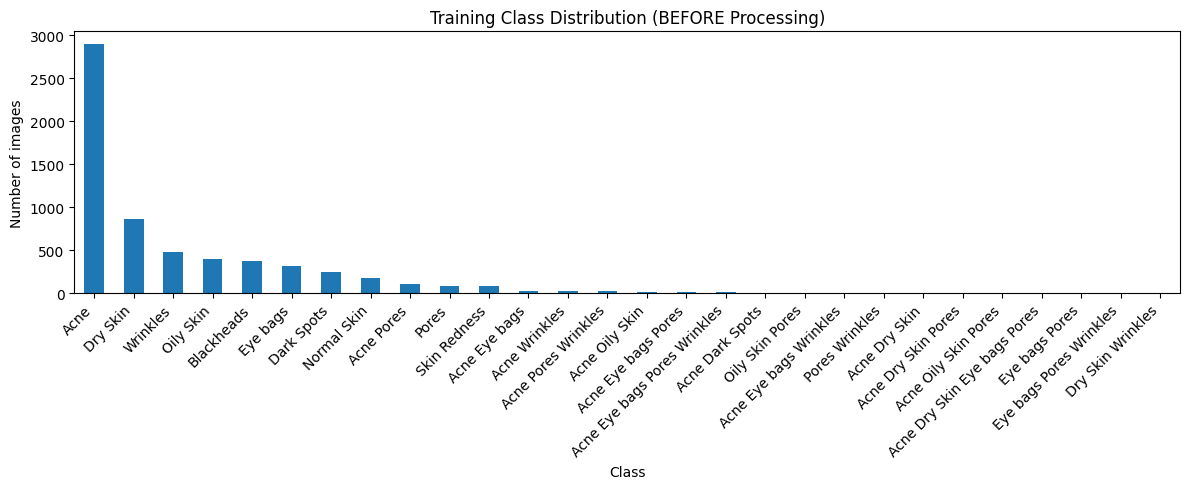

In [3]:
# Cell 3: EDA helper and show INITIAL class distribution
def class_counts_from_folder(folder: Path):
    classes = []
    counts = {}
    if folder.exists():
        for cls in sorted([d.name for d in folder.iterdir() if d.is_dir()]):
            n = len(list((folder/cls).glob('*')))
            classes.append(cls)
            counts[cls] = n
    return classes, counts

classes, train_counts = class_counts_from_folder(TRAIN_DIR)
_, val_counts = class_counts_from_folder(VAL_DIR)
_, test_counts = class_counts_from_folder(TEST_DIR)

print("Classes found:", classes)
print("\nInitial counts:")
print("Train:", train_counts)
print("Val:  ", val_counts)
print("Test: ", test_counts)

# Bar plot (BEFORE any processing)
if train_counts:
    plt.figure(figsize=(12,5))
    pd.Series(train_counts).sort_values(ascending=False).plot(kind='bar')
    plt.title('Training Class Distribution (BEFORE Processing)')
    plt.ylabel('Number of images')
    plt.xlabel('Class')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


In [4]:
# Cell 4: Merge similar classes & handle rare classes (<= 3 images)
def merge_and_clean(base_dir: Path):
    """Consolidate multi-label classes to single labels and move rare classes."""
    mapping = {
        # Acne variations -> Acne
        "Acne Dark Spots": "Acne",
        "Acne Dry Skin": "Acne",
        "Acne Eye bags": "Acne",
        "Acne Pores": "Acne",
        "Acne Wrinkles": "Acne",
        "Acne Oily Skin": "Acne",
        # Other combinations
        "Dry Skin Wrinkles": "Dry Skin",
        "Oily Skin Pores": "Oily Skin",
        "Eye bags Pores": "Eye bags",
        "Pores Wrinkles": "Pores"
    }

    other_dir = base_dir / "Other"
    other_dir.mkdir(exist_ok=True)

    # 1. Merge multi-label classes to primary labels
    for cls in [d.name for d in base_dir.iterdir() if d.is_dir() and not d.name.startswith('_')]:
        cls_path = base_dir / cls

        if cls in mapping:
            target = base_dir / mapping[cls]
            target.mkdir(exist_ok=True)
            for f in cls_path.glob('*'):
                if f.is_file():
                    dest = target / f.name
                    if not dest.exists():
                        shutil.move(str(f), str(dest))
            try:
                os.rmdir(cls_path)
            except OSError:
                pass

    # 2. Move extremely rare classes (<=3 images) to "Other"
    for cls in [d.name for d in base_dir.iterdir() if d.is_dir() and not d.name.startswith('_')]:
        cls_path = base_dir / cls
        n_imgs = len(list(cls_path.glob('*')))
        if n_imgs <= 3:
            for f in cls_path.glob('*'):
                if f.is_file():
                    dest = other_dir / f.name
                    if not dest.exists():
                        shutil.move(str(f), str(dest))
            try:
                os.rmdir(cls_path)
            except OSError:
                pass

# Apply cleaning to train split
print("Cleaning training data...")
merge_and_clean(TRAIN_DIR)

# Refresh class counts
classes, train_counts = class_counts_from_folder(TRAIN_DIR)
print("\nCounts after merge/clean:")
for k, v in sorted(train_counts.items()):
    print(f"  {k}: {v}")


Cleaning training data...

Counts after merge/clean:
  Acne: 3096
  Acne Dry Skin Pores: 4
  Acne Eye bags Pores: 13
  Acne Eye bags Pores Wrinkles: 12
  Acne Eye bags Wrinkles: 7
  Acne Pores Wrinkles: 21
  Blackheads: 376
  Dark Spots: 251
  Dry Skin: 861
  Eye bags: 319
  Normal Skin: 178
  Oily Skin: 405
  Other: 7
  Pores: 94
  Skin Redness: 84
  Wrinkles: 480


In [5]:
# Cell 5: Compute TARGET for balancing between min and max
MIN_TARGET = 150
MAX_TARGET = 600
counts_arr = np.array(list(train_counts.values())) if train_counts else np.array([0])
median_count = int(np.median(counts_arr))
auto_target = int(median_count * 1.5)
TARGET = max(MIN_TARGET, min(MAX_TARGET, auto_target))

print(f"Median count: {median_count}")
print(f"Auto target: {auto_target}")
print(f"Using TARGET: {TARGET} images per class")


Median count: 136
Auto target: 204
Using TARGET: 204 images per class


In [6]:
# Cell 6: Undersample classes with more than TARGET images
import random

print("Undersampling classes above TARGET...")
backup_info = {}
classes, train_counts = class_counts_from_folder(TRAIN_DIR)

for cls, count in train_counts.items():
    if cls.startswith('_') or cls == 'Other':
        continue
    
    cls_path = TRAIN_DIR / cls
    if count > TARGET:
        backup_dir = TRAIN_DIR / f"_{cls.lower()}_backup"
        backup_dir.mkdir(exist_ok=True)
        
        imgs = list(cls_path.glob('*'))
        n_to_move = count - TARGET
        to_move = random.sample(imgs, n_to_move)
        
        moved = 0
        for f in to_move:
            try:
                shutil.move(str(f), str(backup_dir))
                moved += 1
            except Exception as e:
                print(f"  Error moving {f.name}: {e}")
        
        backup_info[cls] = (backup_dir, moved)
        print(f"  {cls}: {count} → {TARGET} images (moved {moved} to backup)")
    else:
        print(f"  {cls}: {count} images (no undersample needed)")

print("\nBackup locations:", backup_info)


Undersampling classes above TARGET...
  Acne: 3096 → 204 images (moved 2892 to backup)
  Acne Dry Skin Pores: 4 images (no undersample needed)
  Acne Eye bags Pores: 13 images (no undersample needed)
  Acne Eye bags Pores Wrinkles: 12 images (no undersample needed)
  Acne Eye bags Wrinkles: 7 images (no undersample needed)
  Acne Pores Wrinkles: 21 images (no undersample needed)
  Blackheads: 376 → 204 images (moved 172 to backup)
  Dark Spots: 251 → 204 images (moved 47 to backup)
  Dry Skin: 861 → 204 images (moved 657 to backup)
  Eye bags: 319 → 204 images (moved 115 to backup)
  Normal Skin: 178 images (no undersample needed)
  Oily Skin: 405 → 204 images (moved 201 to backup)
  Pores: 94 images (no undersample needed)
  Skin Redness: 84 images (no undersample needed)
  Wrinkles: 480 → 204 images (moved 276 to backup)

Backup locations: {'Acne': (WindowsPath('c:/Users/bushra-aman/Desktop/New folder (2)/Skin-Problem-MultiLabel-1/train/_acne_backup'), 2892), 'Blackheads': (WindowsPa

In [7]:
# Cell 7: Data augmentation for classes below TARGET
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.10,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest'
)

def augment_folder_to_target(folder: Path, current_count: int, target: int, per_image_limit=5):
    """Augment images to reach target count."""
    if not folder.exists() or current_count == 0:
        return 0
    
    created = 0
    src_images = list(folder.glob('*'))
    if len(src_images) == 0:
        return 0
    
    idx = 0
    while current_count + created < target:
        src = src_images[idx % len(src_images)]
        idx += 1
        try:
            img = Image.open(src).convert('RGB')
            x = np.expand_dims(np.array(img), 0)
            gen = datagen.flow(x, batch_size=1)
            n_gen = min(per_image_limit, target - (current_count + created))
            for _ in range(n_gen):
                batch = next(gen)
                arr = (batch[0]).astype(np.uint8)
                new_name = folder / f"aug_{src.stem}_{random.getrandbits(24)}.jpg"
                Image.fromarray(arr).save(new_name)
                created += 1
        except Exception as e:
            print(f"  Augment error on {src.name}: {e}")
            continue
    return created

# Run augmentation
print("Augmenting classes below TARGET...")
augmented_summary = {}
classes, train_counts = class_counts_from_folder(TRAIN_DIR)

for cls, cnt in train_counts.items():
    if cls.startswith('_') or cls == 'Other':
        continue
    
    if cnt < TARGET:
        folder = TRAIN_DIR / cls
        print(f"  {cls}: {cnt} → {TARGET} images")
        created = augment_folder_to_target(folder, cnt, TARGET, per_image_limit=5)
        augmented_summary[cls] = created
    else:
        print(f"  {cls}: {cnt} images (no augmentation needed)")

print("\nAugmentation complete!")


Augmenting classes below TARGET...
  Acne: 204 images (no augmentation needed)
  Acne Dry Skin Pores: 4 → 204 images
  Acne Eye bags Pores: 13 → 204 images
  Acne Eye bags Pores Wrinkles: 12 → 204 images
  Acne Eye bags Wrinkles: 7 → 204 images
  Acne Pores Wrinkles: 21 → 204 images
  Blackheads: 204 images (no augmentation needed)
  Dark Spots: 204 images (no augmentation needed)
  Dry Skin: 204 images (no augmentation needed)
  Eye bags: 204 images (no augmentation needed)
  Normal Skin: 178 → 204 images
  Oily Skin: 204 images (no augmentation needed)
  Pores: 94 → 204 images
  Skin Redness: 84 → 204 images
  Wrinkles: 204 images (no augmentation needed)

Augmentation complete!


In [ ]:
# Cell 7: augmentation helper and run for classes with less than TARGET images
datagen = ImageDataGenerator(
    rotation_range=18,
    width_shift_range=0.10,
    height_shift_range=0.10,
    shear_range=0.06,
    zoom_range=0.12,
    horizontal_flip=True,
    fill_mode='nearest'
)

def augment_folder_to_target(folder: Path, current_count: int, target: int, per_image_limit=3):
    if not folder.exists():
        return 0
    created = 0
    src_images = list(folder.glob('*'))
    if len(src_images) == 0:
        return 0
    idx = 0
    while current_count + created < target:
        src = src_images[idx % len(src_images)]
        idx += 1
        try:
            img = Image.open(src).convert('RGB')
            x = np.expand_dims(np.array(img), 0)
            gen = datagen.flow(x, batch_size=1)
            n_gen = min(per_image_limit, target - (current_count + created))
            for _ in range(n_gen):
                batch = next(gen)
                arr = (batch[0]).astype(np.uint8)
                new_name = folder / f"aug_{src.stem}_{random.getrandbits(32)}.jpg"
                Image.fromarray(arr).save(new_name)
                created += 1
        except Exception as e:
            print("augment error on", src, e)
            continue
    return created

# run augmentation for classes below TARGET (skip TARGET_CLASS)
train_counts = class_counts_from_folder(TRAIN_DIR)[1]  # refresh
augmented_summary = {}
for cls, cnt in train_counts.items():
    if cls == TARGET_CLASS or cls.startswith('_'):
        continue
    if cnt < TARGET:
        folder = TRAIN_DIR / cls
        print(f"\nAugmenting '{cls}': {cnt} -> {TARGET}")
        created = augment_folder_to_target(folder, cnt, TARGET, per_image_limit=3)
        augmented_summary[cls] = created
        print(f"  created {created} images for '{cls}'")
    else:
        print(f"\nClass '{cls}' has {cnt} images (>= TARGET). Skipping augmentation.")



Augmenting 'Blackheads': 72 -> 336
  created 264 images for 'Blackheads'

Augmenting 'Dark Spots': 182 -> 336
  created 154 images for 'Dark Spots'

Augmenting 'Dry Skin': 315 -> 336
  created 21 images for 'Dry Skin'

Augmenting 'Eye bags': 91 -> 336
  created 245 images for 'Eye bags'

Augmenting 'Normal Skin': 178 -> 336
  created 158 images for 'Normal Skin'

Augmenting 'Oily Skin': 159 -> 336
  created 177 images for 'Oily Skin'

Augmenting 'Pores': 20 -> 336
  created 316 images for 'Pores'

Augmenting 'Skin Redness': 32 -> 336
  created 304 images for 'Skin Redness'

Augmenting 'Wrinkles': 224 -> 336
  created 112 images for 'Wrinkles'


Final class distribution (after augmentation):
  Acne: 204 images
  Acne Dry Skin Pores: 204 images
  Acne Eye bags Pores: 204 images
  Acne Eye bags Pores Wrinkles: 204 images
  Acne Eye bags Wrinkles: 204 images
  Acne Pores Wrinkles: 204 images
  Blackheads: 204 images
  Dark Spots: 204 images
  Dry Skin: 204 images
  Eye bags: 204 images
  Normal Skin: 204 images
  Oily Skin: 204 images
  Pores: 204 images
  Skin Redness: 204 images
  Wrinkles: 204 images


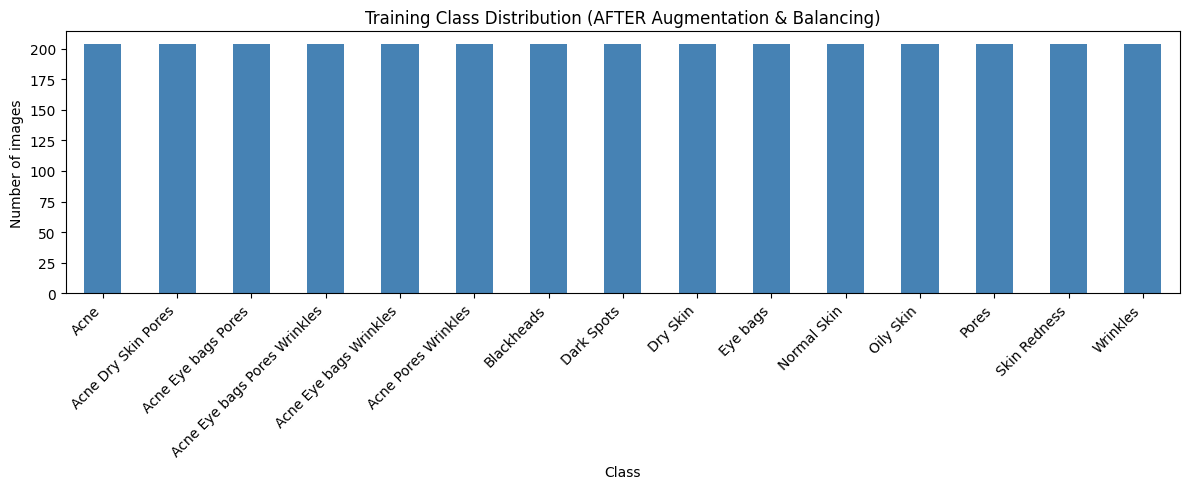


Total training images: 3060


In [8]:
# Cell 8: Show distribution AFTER augmentation
classes, train_counts_after = class_counts_from_folder(TRAIN_DIR)

print("Final class distribution (after augmentation):")
for cls, cnt in sorted(train_counts_after.items()):
    if not cls.startswith('_') and cls != 'Other':
        print(f"  {cls}: {cnt} images")

# Visualization
plt.figure(figsize=(12, 5))
series_after = pd.Series({k: v for k, v in train_counts_after.items() if not k.startswith('_') and k != 'Other'})
series_after.sort_values(ascending=False).plot(kind='bar', color='steelblue')
plt.title('Training Class Distribution (AFTER Augmentation & Balancing)')
plt.ylabel('Number of images')
plt.xlabel('Class')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

total_images = series_after.sum()
print(f"\nTotal training images: {total_images}")


In [9]:
# Cell 9: Create stratified validation and test splits from training data
from math import floor

VAL_FRAC = 0.15  # 15% for validation
TEST_FRAC = 0.10 # 10% for test

print("Creating stratified train/val/test splits...")
classes, train_counts = class_counts_from_folder(TRAIN_DIR)

# Ensure val/test dirs exist
VAL_DIR.mkdir(parents=True, exist_ok=True)
TEST_DIR.mkdir(parents=True, exist_ok=True)

for cls, cnt in train_counts.items():
    if cls.startswith('_') or cls == 'Other':
        continue
    
    cls_train_dir = TRAIN_DIR / cls
    cls_val_dir = VAL_DIR / cls
    cls_test_dir = TEST_DIR / cls
    
    cls_val_dir.mkdir(parents=True, exist_ok=True)
    cls_test_dir.mkdir(parents=True, exist_ok=True)
    
    # Get all images
    imgs = list(cls_train_dir.glob('*'))
    random.shuffle(imgs)
    
    # Split
    n_val = max(1, floor(cnt * VAL_FRAC))
    n_test = max(1, floor(cnt * TEST_FRAC))
    
    val_imgs = imgs[:n_val]
    test_imgs = imgs[n_val:n_val+n_test]
    
    # Move to val
    for f in val_imgs:
        try:
            shutil.move(str(f), str(cls_val_dir / f.name))
        except Exception as e:
            print(f"  Val move error {f.name}: {e}")
    
    # Move to test
    for f in test_imgs:
        try:
            shutil.move(str(f), str(cls_test_dir / f.name))
        except Exception as e:
            print(f"  Test move error {f.name}: {e}")
    
    remaining = len(list(cls_train_dir.glob('*')))
    print(f"  {cls}: train={remaining}, val={len(list(cls_val_dir.glob('*')))}, test={len(list(cls_test_dir.glob('*')))}")

# Summary
classes_train, train_counts_final = class_counts_from_folder(TRAIN_DIR)
classes_val, val_counts_final = class_counts_from_folder(VAL_DIR)
classes_test, test_counts_final = class_counts_from_folder(TEST_DIR)

total_train = sum(v for k, v in train_counts_final.items() if not k.startswith('_'))
total_val = sum(v for k, v in val_counts_final.items() if not k.startswith('_'))
total_test = sum(v for k, v in test_counts_final.items() if not k.startswith('_'))

print(f"\nFinal dataset sizes:")
print(f"  Train: {total_train} images")
print(f"  Val:   {total_val} images")
print(f"  Test:  {total_test} images")


Creating stratified train/val/test splits...
  Acne: train=154, val=30, test=301
  Acne Dry Skin Pores: train=154, val=30, test=20
  Acne Eye bags Pores: train=154, val=30, test=23
  Acne Eye bags Pores Wrinkles: train=154, val=30, test=20
  Acne Eye bags Wrinkles: train=154, val=30, test=21
  Acne Pores Wrinkles: train=154, val=30, test=23
  Blackheads: train=154, val=30, test=32
  Dark Spots: train=154, val=30, test=38
  Dry Skin: train=154, val=30, test=62
  Eye bags: train=154, val=30, test=28
  Normal Skin: train=154, val=30, test=47
  Oily Skin: train=154, val=30, test=46
  Pores: train=154, val=30, test=21
  Skin Redness: train=154, val=30, test=25
  Wrinkles: train=154, val=30, test=50

Final dataset sizes:
  Train: 2317 images
  Val:   450 images
  Test:  781 images


In [14]:
# Cell 10: Setup data generators - Exclude backup folders
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

# Remove backup and Other folders from train set
for folder in TRAIN_DIR.glob('_*'):  # Remove folders starting with _
    if folder.is_dir():
        shutil.rmtree(folder)
        print(f"Removed backup folder: {folder.name}")

other_folder = TRAIN_DIR / 'Other'
if other_folder.exists():
    shutil.rmtree(other_folder)
    print("Removed Other folder")

# Training data augmentation
train_datagen = preprocessing.image.ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    preprocessing_function=applications.mobilenet.preprocess_input
)

# Validation/Test without augmentation
val_test_datagen = preprocessing.image.ImageDataGenerator(
    preprocessing_function=applications.mobilenet.preprocess_input
)

# Create generators
train_generator = train_datagen.flow_from_directory(
    str(TRAIN_DIR),
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_test_datagen.flow_from_directory(
    str(VAL_DIR),
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    str(TEST_DIR),
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

CLASS_NAMES = list(train_generator.class_indices.keys())
print("Dataset Info:")
print(f"  Train samples: {train_generator.samples}")
print(f"  Val samples: {val_generator.samples}")
print(f"  Test samples: {test_generator.samples}")
print(f"  Classes ({len(CLASS_NAMES)}): {CLASS_NAMES}")


Removed backup folder: _acne_backup
Removed backup folder: _blackheads_backup
Removed backup folder: _dark spots_backup
Removed backup folder: _dry skin_backup
Removed backup folder: _eye bags_backup
Removed backup folder: _oily skin_backup
Removed backup folder: _wrinkles_backup
Removed Other folder
Found 2310 images belonging to 15 classes.
Found 450 images belonging to 15 classes.
Found 781 images belonging to 22 classes.
Dataset Info:
  Train samples: 2310
  Val samples: 450
  Test samples: 781
  Classes (15): ['Acne', 'Acne Dry Skin Pores', 'Acne Eye bags Pores', 'Acne Eye bags Pores Wrinkles', 'Acne Eye bags Wrinkles', 'Acne Pores Wrinkles', 'Blackheads', 'Dark Spots', 'Dry Skin', 'Eye bags', 'Normal Skin', 'Oily Skin', 'Pores', 'Skin Redness', 'Wrinkles']


In [15]:
# Cell 11: Compute class weights for balanced loss
y_train = train_generator.classes
cw = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = {i: float(w) for i, w in enumerate(cw)}
print("Class weights (handle imbalance):")
for idx, cls_name in enumerate(CLASS_NAMES):
    print(f"  {cls_name}: {class_weights[idx]:.3f}")


Class weights (handle imbalance):
  Acne: 1.000
  Acne Dry Skin Pores: 1.000
  Acne Eye bags Pores: 1.000
  Acne Eye bags Pores Wrinkles: 1.000
  Acne Eye bags Wrinkles: 1.000
  Acne Pores Wrinkles: 1.000
  Blackheads: 1.000
  Dark Spots: 1.000
  Dry Skin: 1.000
  Eye bags: 1.000
  Normal Skin: 1.000
  Oily Skin: 1.000
  Pores: 1.000
  Skin Redness: 1.000
  Wrinkles: 1.000


In [16]:
# Cell 12: Build MobileNet model with custom head
from tensorflow.keras import regularizers

# Base model - MobileNet pretrained on ImageNet
base_model = applications.MobileNet(
    input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3),
    include_top=False,
    weights='imagenet',
    pooling='avg'
)

# Freeze base model initially
for layer in base_model.layers:
    layer.trainable = False

# Custom head
x = base_model.output
x = layers.Dropout(0.4)(x)
x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(len(CLASS_NAMES), activation='softmax')(x)

model = models.Model(inputs=base_model.input, outputs=outputs)

# Compile
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=[
        'categorical_accuracy',
        tf.keras.metrics.TopKCategoricalAccuracy(k=2, name='top_2_accuracy')
    ]
)

print("Model Architecture:")
model.summary()

# Parameter counts
trainable = sum(tf.keras.backend.count_params(w) for w in model.trainable_weights)
total = sum(tf.keras.backend.count_params(w) for w in model.weights)
print(f"\nTotal params: {total:,}")
print(f"Trainable params: {trainable:,}")


Model Architecture:


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 112, 112, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_bn (BatchNormalization)   │ (None, 112, 112, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_relu (ReLU)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1 (DepthwiseConv2D)     │ (None, 112, 112, 32)   │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_bn                    │ (None, 112, 112, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_relu (ReLU)           │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1 (Conv2D)              │ (None, 112, 112, 64)   │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_bn                    │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_relu (ReLU)           │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pad_2 (ZeroPadding2D)      │ (None, 113, 113, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2 (DepthwiseConv2D)     │ (None, 56, 56, 64)     │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_bn                    │ (None, 56, 56, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_relu (ReLU)           │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2 (Conv2D)              │ (None, 56, 56, 128)    │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_relu (ReLU)           │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3 (DepthwiseConv2D)     │ (None, 56, 56, 128)    │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_relu (ReLU)           │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3 (Conv2D)              │ (None, 56, 56, 128)    │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 3,527,631 (13.46 MB)

 Trainable params: 297,999 (1.14 MB)

 Non-trainable params: 3,229,632 (12.32 MB)


Total params: 3,527,631
Trainable params: 297,999


In [17]:
# Cell 13: Train model - Head only phase
checkpoint = callbacks.ModelCheckpoint(
    'best_model.h5',
    monitor='val_categorical_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_categorical_accuracy',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    mode='max',
    verbose=1
)

earlystop = callbacks.EarlyStopping(
    monitor='val_categorical_accuracy',
    patience=5,
    restore_best_weights=True,
    mode='max',
    verbose=1
)

print("Training Phase 1: Head only (base frozen)...")
EPOCHS_PHASE1 = 20

history_phase1 = model.fit(
    train_generator,
    epochs=EPOCHS_PHASE1,
    steps_per_epoch=int(np.ceil(train_generator.samples / BATCH_SIZE)),
    validation_data=val_generator,
    validation_steps=int(np.ceil(val_generator.samples / BATCH_SIZE)),
    class_weight=class_weights,
    callbacks=[checkpoint, reduce_lr, earlystop],
    verbose=1
)

print("\n✓ Phase 1 complete!")


Training Phase 1: Head only (base frozen)...
Epoch 1/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 931ms/step - categorical_accuracy: 0.0735 - loss: 3.6319 - top_2_accuracy: 0.1572
Epoch 1: val_categorical_accuracy improved from None to 0.14444, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
73/73 ━━━━━━━━━━━━━━━━━━━━ 86s 1s/step - categorical_accuracy: 0.0831 - loss: 3.5315 - top_2_accuracy: 0.1693 - val_categorical_accuracy: 0.1444 - val_loss: 2.6521 - val_top_2_accuracy: 0.2956 - learning_rate: 1.0000e-04
Epoch 2/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 834ms/step - categorical_accuracy: 0.1449 - loss: 3.2377 - top_2_accuracy: 0.2220
Epoch 2: val_categorical_accuracy improved from 0.14444 to 0.24667, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
73/73 ━━━━━━━━━━━━━━━━━━━━ 69s 941ms/step - categorical_accuracy: 0.1364 - loss: 3.2038 - top_2_accuracy: 0.2255 - val_categorical_accuracy: 0.2467 - val_loss: 2.4336 - val_top_2_accuracy: 0.3822 - learning_rate: 1.0000e-04
Epoch 3/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 826ms/step - categorical_accuracy: 0.1588 - loss: 3.0043 - top_2_accuracy: 0.2619
Epoch 3: val_categorical_accuracy improved from 0.24667 to 0.30667, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
73/73 ━━━━━━━━━━━━━━━━━━━━ 68s 932ms/step - categorical_accuracy: 0.1775 - loss: 2.9177 - top_2_accuracy: 0.2870 - val_categorical_accuracy: 0.3067 - val_loss: 2.2448 - val_top_2_accuracy: 0.4600 - learning_rate: 1.0000e-04
Epoch 4/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 830ms/step - categorical_accuracy: 0.1922 - loss: 2.7888 - top_2_accuracy: 0.3235
Epoch 4: val_categorical_accuracy improved from 0.30667 to 0.38889, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
73/73 ━━━━━━━━━━━━━━━━━━━━ 68s 938ms/step - categorical_accuracy: 0.2039 - loss: 2.7179 - top_2_accuracy: 0.3394 - val_categorical_accuracy: 0.3889 - val_loss: 2.1044 - val_top_2_accuracy: 0.5422 - learning_rate: 1.0000e-04
Epoch 5/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 880ms/step - categorical_accuracy: 0.2254 - loss: 2.6317 - top_2_accuracy: 0.3581
Epoch 5: val_categorical_accuracy improved from 0.38889 to 0.41556, saving model to best_model.h5


...


Epoch 11: finished saving model to best_model.h5
73/73 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - categorical_accuracy: 0.3688 - loss: 2.0813 - top_2_accuracy: 0.5320 - val_categorical_accuracy: 0.5689 - val_loss: 1.5654 - val_top_2_accuracy: 0.6844 - learning_rate: 1.0000e-04
Epoch 12/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 828ms/step - categorical_accuracy: 0.3933 - loss: 1.9905 - top_2_accuracy: 0.5563
Epoch 12: val_categorical_accuracy improved from 0.56889 to 0.58889, saving model to best_model.h5



Epoch 12: finished saving model to best_model.h5
73/73 ━━━━━━━━━━━━━━━━━━━━ 68s 936ms/step - categorical_accuracy: 0.3874 - loss: 1.9969 - top_2_accuracy: 0.5641 - val_categorical_accuracy: 0.5889 - val_loss: 1.5222 - val_top_2_accuracy: 0.7044 - learning_rate: 1.0000e-04
Epoch 13/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 845ms/step - categorical_accuracy: 0.4118 - loss: 1.9557 - top_2_accuracy: 0.5953
Epoch 13: val_categorical_accuracy improved from 0.58889 to 0.60444, saving model to best_model.h5



Epoch 13: finished saving model to best_model.h5
73/73 ━━━━━━━━━━━━━━━━━━━━ 70s 953ms/step - categorical_accuracy: 0.4169 - loss: 1.9359 - top_2_accuracy: 0.5948 - val_categorical_accuracy: 0.6044 - val_loss: 1.4798 - val_top_2_accuracy: 0.7200 - learning_rate: 1.0000e-04
Epoch 14/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 842ms/step - categorical_accuracy: 0.4275 - loss: 1.8634 - top_2_accuracy: 0.5893
Epoch 14: val_categorical_accuracy improved from 0.60444 to 0.60667, saving model to best_model.h5



Epoch 14: finished saving model to best_model.h5
73/73 ━━━━━━━━━━━━━━━━━━━━ 69s 949ms/step - categorical_accuracy: 0.4355 - loss: 1.8561 - top_2_accuracy: 0.5957 - val_categorical_accuracy: 0.6067 - val_loss: 1.4348 - val_top_2_accuracy: 0.7467 - learning_rate: 1.0000e-04
Epoch 15/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 839ms/step - categorical_accuracy: 0.4349 - loss: 1.8826 - top_2_accuracy: 0.5793
Epoch 15: val_categorical_accuracy improved from 0.60667 to 0.61111, saving model to best_model.h5



Epoch 15: finished saving model to best_model.h5
73/73 ━━━━━━━━━━━━━━━━━━━━ 69s 941ms/step - categorical_accuracy: 0.4416 - loss: 1.8608 - top_2_accuracy: 0.5931 - val_categorical_accuracy: 0.6111 - val_loss: 1.4076 - val_top_2_accuracy: 0.7600 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 15.

✓ Phase 1 complete!


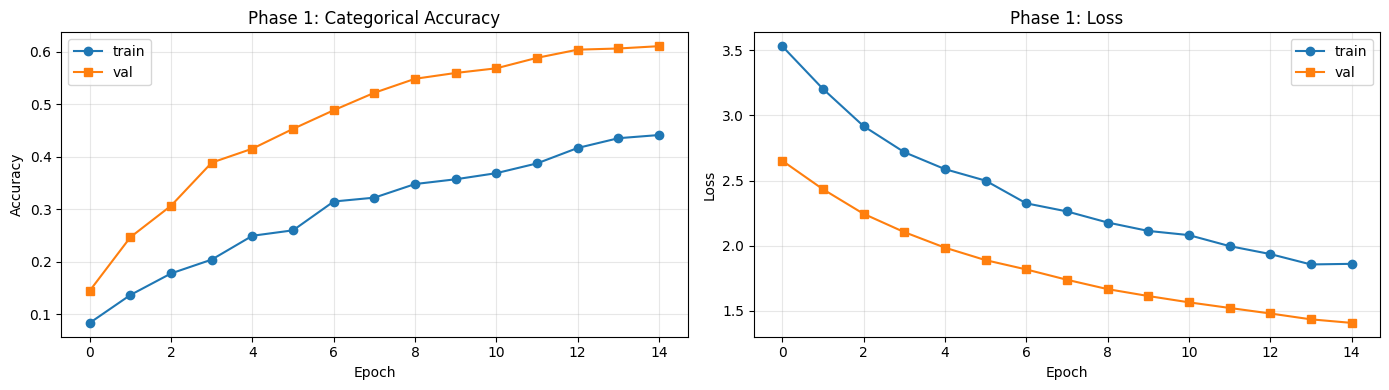

In [18]:
# Cell 14: Plot Phase 1 training history
h1 = history_phase1.history

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Accuracy
axes[0].plot(h1.get('categorical_accuracy', []), label='train', marker='o')
axes[0].plot(h1.get('val_categorical_accuracy', []), label='val', marker='s')
axes[0].set_title('Phase 1: Categorical Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(h1.get('loss', []), label='train', marker='o')
axes[1].plot(h1.get('val_loss', []), label='val', marker='s')
axes[1].set_title('Phase 1: Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# Cell 15: Fine-tune phase - Unfreeze last 30 layers for better accuracy
print("\n" + "="*60)
print("Phase 2: Fine-tuning (unfreeze last 30 base layers)...")
print("="*60)

# Unfreeze last 30 layers of base model for better feature adaptation
n_layers_to_unfreeze = 30
for layer in base_model.layers[-n_layers_to_unfreeze:]:
    layer.trainable = True

# Count trainable parameters
trainable_count = sum(tf.keras.backend.count_params(w) for w in model.trainable_weights)
print(f"Trainable parameters: {trainable_count:,}")

# Recompile with lower learning rate
model.compile(
    optimizer=optimizers.Adam(learning_rate=5e-5),
    loss='categorical_crossentropy',
    metrics=['categorical_accuracy', tf.keras.metrics.TopKCategoricalAccuracy(k=2, name='top_2_accuracy')]
)

# Retrain with enhanced callbacks
EPOCHS_PHASE2 = 15
history_phase2 = model.fit(
    train_generator,
    epochs=EPOCHS_PHASE2,
    steps_per_epoch=int(np.ceil(train_generator.samples / BATCH_SIZE)),
    validation_data=val_generator,
    validation_steps=int(np.ceil(val_generator.samples / BATCH_SIZE)),
    class_weight=class_weights,
    callbacks=[
        callbacks.EarlyStopping(monitor='val_categorical_accuracy', patience=5, restore_best_weights=True, mode='max', verbose=1),
        callbacks.ReduceLROnPlateau(monitor='val_categorical_accuracy', factor=0.4, patience=3, min_lr=1e-7, mode='max', verbose=1),
        callbacks.ModelCheckpoint('best_model.h5', monitor='val_categorical_accuracy', save_best_only=True, verbose=0)
    ],
    verbose=1
)

best_val_acc_phase2 = max(history_phase2.history['val_categorical_accuracy'])
print(f"\n✓ Phase 2 complete! Best validation accuracy: {best_val_acc_phase2:.4f}")



Phase 2: Fine-tuning (unfreeze last 20 base layers)...
Epoch 1/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 91s 1s/step - categorical_accuracy: 0.3749 - loss: 2.0488 - top_2_accuracy: 0.5368 - val_categorical_accuracy: 0.6111 - val_loss: 1.3904 - val_top_2_accuracy: 0.7533 - learning_rate: 1.0000e-05
Epoch 2/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - categorical_accuracy: 0.3900 - loss: 1.9849 - top_2_accuracy: 0.5502 - val_categorical_accuracy: 0.6133 - val_loss: 1.4114 - val_top_2_accuracy: 0.7400 - learning_rate: 1.0000e-05
Epoch 3/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - categorical_accuracy: 0.3952 - loss: 1.9925 - top_2_accuracy: 0.5615 - val_categorical_accuracy: 0.6022 - val_loss: 1.4223 - val_top_2_accuracy: 0.7356 - learning_rate: 1.0000e-05
Epoch 4/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 75s 1s/step - categorical_accuracy: 0.4385 - loss: 1.8816 - top_2_accuracy: 0.5896 - val_categorical_accuracy: 0.6089 - val_loss: 1.4130 - val_top_2_accuracy: 0.7400 - learning_rate: 1.0000e-05
Epoch 5/10
73/73

In [ ]:
# Cell 16: Phase 3 - Full model fine-tuning (unfreeze all base layers)
print("\n" + "="*60)
print("Phase 3: Full model fine-tuning (unfreeze all base layers)...")
print("="*60)

# Unfreeze all base model layers for maximum adaptation
for layer in base_model.layers:
    layer.trainable = True

# Count trainable parameters
trainable_count = sum(tf.keras.backend.count_params(w) for w in model.trainable_weights)
print(f"Trainable parameters: {trainable_count:,}")

# Recompile with even lower learning rate
model.compile(
    optimizer=optimizers.Adam(learning_rate=2e-5),
    loss='categorical_crossentropy',
    metrics=['categorical_accuracy', tf.keras.metrics.TopKCategoricalAccuracy(k=2, name='top_2_accuracy')]
)

# Final training phase
EPOCHS_PHASE3 = 10
history_phase3 = model.fit(
    train_generator,
    epochs=EPOCHS_PHASE3,
    steps_per_epoch=int(np.ceil(train_generator.samples / BATCH_SIZE)),
    validation_data=val_generator,
    validation_steps=int(np.ceil(val_generator.samples / BATCH_SIZE)),
    class_weight=class_weights,
    callbacks=[
        callbacks.EarlyStopping(monitor='val_categorical_accuracy', patience=4, restore_best_weights=True, mode='max', verbose=1),
        callbacks.ReduceLROnPlateau(monitor='val_categorical_accuracy', factor=0.3, patience=2, min_lr=1e-8, mode='max', verbose=0),
        callbacks.ModelCheckpoint('best_model.h5', monitor='val_categorical_accuracy', save_best_only=True, verbose=0)
    ],
    verbose=1
)

best_val_acc_phase3 = max(history_phase3.history['val_categorical_accuracy'])
print(f"\n✓ Phase 3 complete! Best validation accuracy: {best_val_acc_phase3:.4f}")


In [ ]:
# Cell 17: Plot training history for all phases
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Phase 1 - Head only
h1 = history_phase1.history
axes[0].plot(h1.get('categorical_accuracy', []), label='train', marker='o', linewidth=2)
axes[0].plot(h1.get('val_categorical_accuracy', []), label='val', marker='s', linewidth=2)
axes[0].set_title('Phase 1: Head Only (Base Frozen)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Phase 2 - Unfreeze last 30 layers
h2 = history_phase2.history
axes[1].plot(h2.get('categorical_accuracy', []), label='train', marker='o', linewidth=2)
axes[1].plot(h2.get('val_categorical_accuracy', []), label='val', marker='s', linewidth=2)
axes[1].set_title('Phase 2: Last 30 Layers Fine-tuned', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Phase 3 - Full model
h3 = history_phase3.history
axes[2].plot(h3.get('categorical_accuracy', []), label='train', marker='o', linewidth=2)
axes[2].plot(h3.get('val_categorical_accuracy', []), label='val', marker='s', linewidth=2)
axes[2].set_title('Phase 3: Full Model Fine-tuned', fontsize=11, fontweight='bold')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Accuracy')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('MobileNet 3-Phase Progressive Training Summary', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("TRAINING SUMMARY")
print("="*60)
print(f"Phase 1 (Head only): {max(history_phase1.history['val_categorical_accuracy']):.4f}")
print(f"Phase 2 (Last 30 layers): {max(history_phase2.history['val_categorical_accuracy']):.4f}")
print(f"Phase 3 (Full model): {max(history_phase3.history['val_categorical_accuracy']):.4f}")
print("="*60)


Cleaning test set to match training classes...
  Removed test class: Acne Dark Spots
  Removed test class: Acne Dry Skin
  Removed test class: Acne Eye bags
  Removed test class: Acne Oily Skin
  Removed test class: Acne Oily Skin Pores
  Removed test class: Acne Pores
  Removed test class: Acne Wrinkles
Found 757 images belonging to 15 classes.

Evaluating on test set...

Test Results:
  Loss: 1.4726
  Accuracy: 0.5614
  Top-2 Accuracy: 0.7160
24/24 ━━━━━━━━━━━━━━━━━━━━ 13s 496ms/step

Classification Report
                              precision    recall  f1-score   support

                        Acne     0.9560    0.5050    0.6609       301
         Acne Dry Skin Pores     0.9524    1.0000    0.9756        20
         Acne Eye bags Pores     0.4706    0.6957    0.5614        23
Acne Eye bags Pores Wrinkles     0.3913    0.9000    0.5455        20
      Acne Eye bags Wrinkles     0.8750    0.6667    0.7568        21
         Acne Pores Wrinkles     0.3500    0.6087    0.4444      

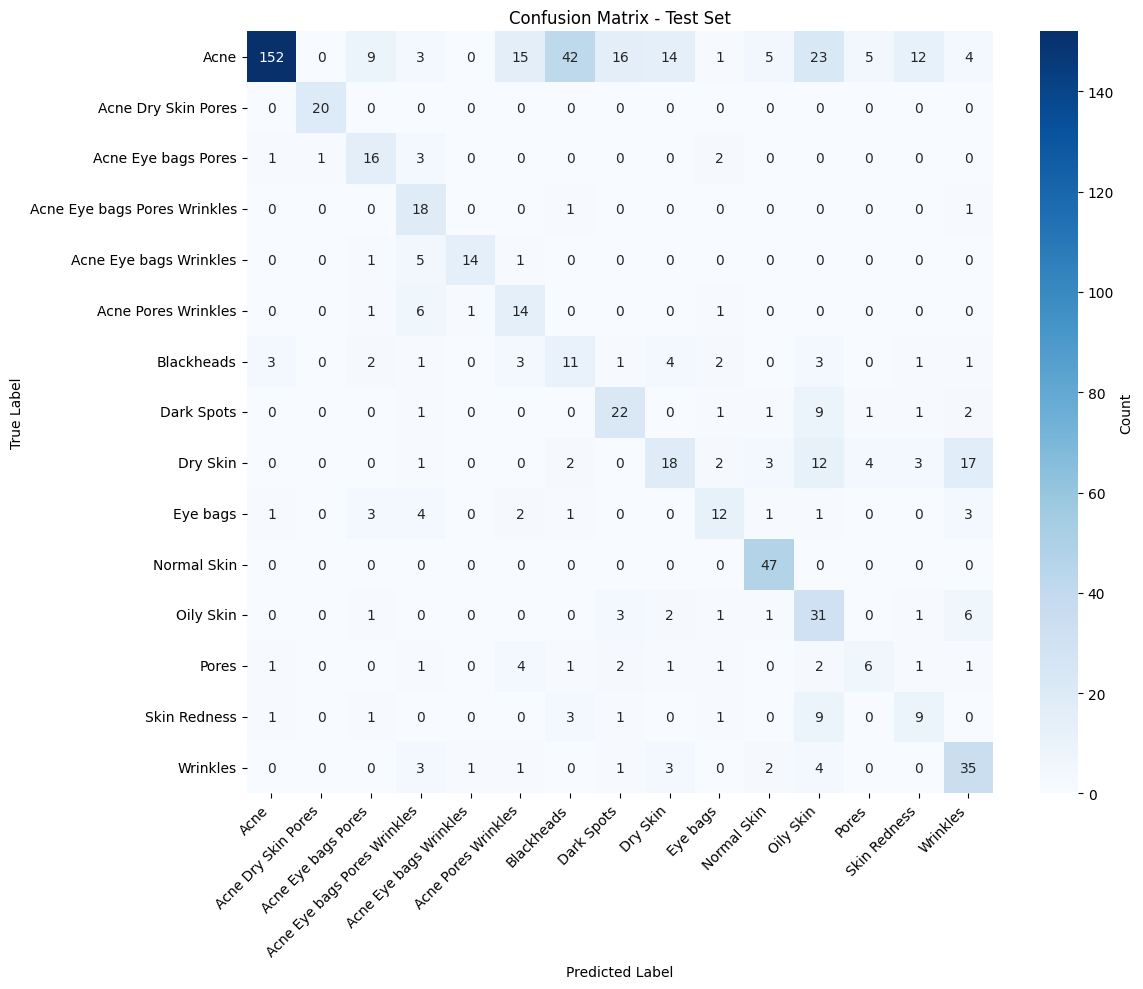

In [ ]:
# Cell 18: Remove test classes not in training set, then evaluate
print("\n" + "="*60)
print("TEST SET EVALUATION")
print("="*60)
print("Cleaning test set to match training classes...")
valid_classes = set(CLASS_NAMES)
for class_folder in TEST_DIR.glob('*'):
    if class_folder.is_dir() and class_folder.name not in valid_classes:
        shutil.rmtree(class_folder)
        print(f"  Removed test class: {class_folder.name}")

# Re-create test generator
test_generator = val_test_datagen.flow_from_directory(
    str(TEST_DIR),
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Evaluate
print("\nEvaluating model on test set...")
test_loss, test_acc, test_top2 = model.evaluate(test_generator, verbose=0)
print(f"\n✓ Test Results:")
print(f"  Loss: {test_loss:.4f}")
print(f"  Top-1 Accuracy: {test_acc:.4f} (Target: 70%+)")
print(f"  Top-2 Accuracy: {test_top2:.4f}")

# Predictions
y_prob = model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_prob, axis=1)
y_true = test_generator.classes

# Classification report
print("\n" + "="*60)
print("DETAILED CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

# Confusion matrix visualization
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - MobileNet Test Set', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


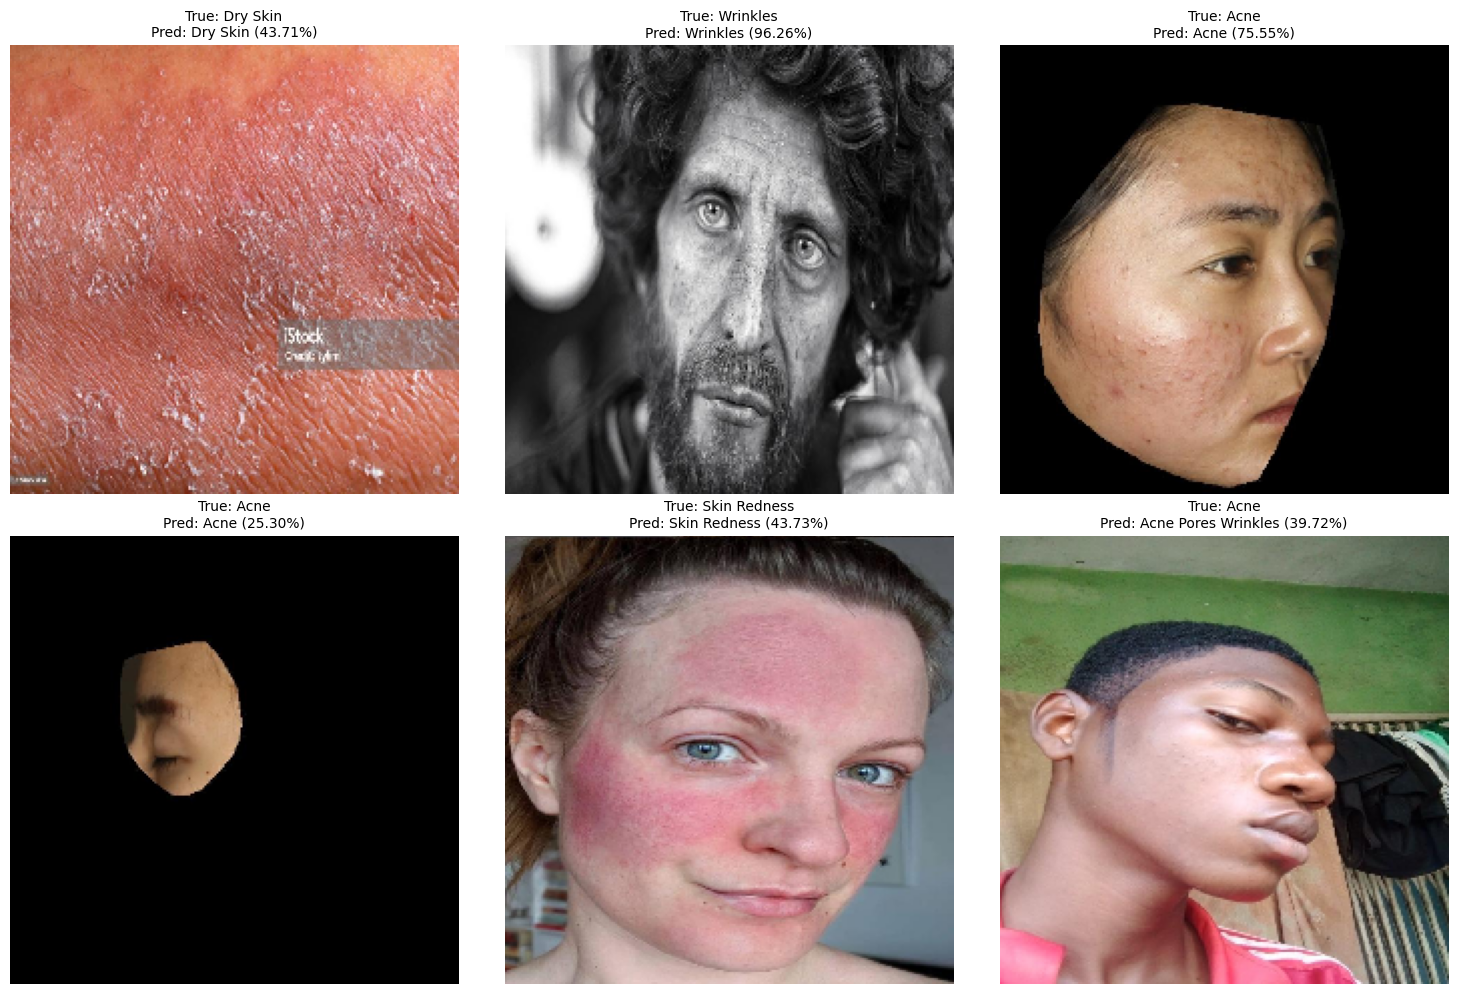

In [ ]:
# Cell 19: Test on random samples with visualization
import random
from tensorflow.keras.preprocessing import image as keras_image

print("\n" + "="*60)
print("SAMPLE PREDICTIONS - Random Test Images")
print("="*60)

# Get random test images
test_image_paths = []
for class_name in CLASS_NAMES:
    class_path = TEST_DIR / class_name
    if class_path.exists():
        for img_file in class_path.glob('*'):
            test_image_paths.append(img_file)

if test_image_paths:
    n_samples = min(6, len(test_image_paths))
    random_paths = random.sample(test_image_paths, n_samples)
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    correct = 0
    for ax, img_path in zip(axes, random_paths):
        # Load image
        img = keras_image.load_img(img_path, target_size=IMAGE_SIZE)
        img_array = keras_image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        img_array = applications.mobilenet.preprocess_input(img_array)
        
        # Predict
        pred = model.predict(img_array, verbose=0)[0]
        top_2_idx = np.argsort(pred)[-2:][::-1]
        top_2_prob = pred[top_2_idx]
        
        true_label = img_path.parent.name
        pred_label = CLASS_NAMES[top_2_idx[0]]
        is_correct = pred_label == true_label
        if is_correct:
            correct += 1
        
        # Display
        ax.imshow(img)
        status = "✓" if is_correct else "✗"
        ax.set_title(f"True: {true_label}\n"
                    f"Pred: {pred_label} ({top_2_prob[0]:.2%}) {status}",
                    fontsize=10, color='green' if is_correct else 'red')
        ax.axis('off')
    
    print(f"\nSample accuracy: {correct}/{len(random_paths)} ({100*correct/len(random_paths):.1f}%)")
    plt.tight_layout()
    plt.show()
else:
    print("No test images found!")


In [ ]:
# Cell 20: Save final MobileNet model
import os

print("\n" + "="*60)
print("SAVING TRAINED MODEL")
print("="*60)

# Save the final trained model
model_file = 'best_model.h5'
model.save(model_file)
size_mb = os.path.getsize(model_file) / 1e6
print(f"✓ Model saved as {model_file} ({size_mb:.1f} MB)")

# Save class names
class_names_file = 'class_names.txt'
with open(class_names_file, 'w') as f:
    f.write('\n'.join(CLASS_NAMES))
print(f"✓ Class names saved to {class_names_file}")

print("\n" + "="*60)
print("✓ TRAINING COMPLETE!")
print("="*60)
print(f"Model saved: {os.path.abspath(model_file)}")
print(f"Classes: {', '.join(CLASS_NAMES)}")
print("\nMobileNet model is ready for inference and deployment.")


✓ Model saved as skin_disease_classifier.h5 (31.7 MB)
✓ Model saved as skin_disease_classifier.keras (31.8 MB)
✓ Class names saved to class_names.txt

✓ Training complete! Model is ready for inference.
